# Домашнее задание "Тематическое моделирование"

## Импорт необходимых библиотек:

In [14]:
# для работы в colab
!pip install pymorphy3

In [15]:
# монтирование google диска для работы в colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import io
import string
import json
import bz2
import pandas as pd
from collections import Counter
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer

from pymorphy3 import MorphAnalyzer

# import regex

# from scipy import sparse


# import numpy as np

# import seaborn as sns

# %pylab inline

In [5]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Выгрузка данных из архива

In [6]:
path_colab = '../content/drive/MyDrive/DeepLearning/banki_responses.json.bz2'
path = 'banki_responses.json.bz2'

In [7]:
responses = []
with bz2.BZ2File(path_colab, 'r') as thefile:
    for row in tqdm(thefile):
        resp = json.loads(row)
        if not resp['rating_not_checked'] and (len(resp['text'].split()) > 0):
            responses.append(resp)

201030it [01:16, 2612.66it/s]


Пример отзыва:

In [8]:
responses[-2:]

[{'city': None,
  'rating_not_checked': False,
  'title': 'В Альфа-Банк больше обращаться не буду.',
  'num_comments': 0,
  'bank_license': 'лицензия № 1326',
  'author': 'Ирина',
  'bank_name': 'Альфа-Банк',
  'datetime': '2005-04-14 15:16:00',
  'text': 'Пробовала 10.04.05 оформить товар в кредит в Альфа-Банке (компьютерный центр "Буденовский"), сказали что все оформление займет 20 минут, в результате прождала 2,5 (!!!!) часа. После чего сказали - приходите завтра. Люди, которые ждали оформления, были также недовольны. На следующий день в кредите отказали, хотя на мой взгляд причин никаких не было, постоянная московская прописка, стабильная зарплата, 2 выплаченных в срок кредита в других банках, да и сумма товара была небольшая.  В общем, на следующий день в том же компьютерном центре я оформила кредит в "HOME CREDIT", оформлен он был за 10 (!!!) минут. А в Альфа-Банк больше обращаться не буду. Остались самые негативные воспоминания.',
  'rating_grade': 1},
 {'city': None,
  'rating_

In [9]:
df = pd.DataFrame(responses)
df.head()

,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade
0,г. Москва,False,Жалоба,0,лицензия № 2562,uhnov1,Бинбанк,2015-06-08 12:50:54,Добрый день! Я не являюсь клиентом банка и пор...,NaN
1,г. Новосибирск,False,Не могу пользоваться услугой Сбербанк он-лайн,0,лицензия № 1481,Foryou,Сбербанк России,2015-06-08 11:09:57,Доброго дня! Являюсь держателем зарплатной кар...,NaN
2,г. Москва,False,Двойное списание за один товар.,1,лицензия № 2562,Vladimir84,Бинбанк,2015-06-05 20:14:28,Здравствуйте! Дублирую свое заявление от 03.0...,NaN
3,г. Ставрополь,False,Меняют проценты комиссии не предупредив и не ...,2,лицензия № 1481,643609,Сбербанк России,2015-06-05 13:51:01,Добрый день!! Я открыл расчетный счет в СберБа...,NaN
4,г. Челябинск,False,Верните денежные средства за страховку,1,лицензия № 2766,anfisa-2003,ОТП Банк,2015-06-05 10:58:12,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN


In [10]:
df_text = df[['text', 'rating_grade']].copy()
df_text.head(5)

,text,rating_grade
0,Добрый день! Я не являюсь клиентом банка и пор...,NaN
1,Доброго дня! Являюсь держателем зарплатной кар...,NaN
2,Здравствуйте! Дублирую свое заявление от 03.0...,NaN
3,Добрый день!! Я открыл расчетный счет в СберБа...,NaN
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN


## Часть 1. Анализ текстов

### 1.1 Посчитать количество отзывов в разных городах и на разные банки

In [12]:
# Количество отзывов в разных городах
num_reviews_by_city = df['city'].value_counts()
num_reviews_by_city

,count
city,
г. Москва,55354
г. Санкт-Петербург,14342
г. Екатеринбург,2337
г. Новосибирск,2300
г. Нижний Новгород,1976
...,...
г. порхов,1
г. город Алматы,1
"г. Казань, Татарстан",1


In [13]:
# Количество отзывов на разные банки
num_reviews_by_bank = df['bank_name'].value_counts()
num_reviews_by_bank

,count
bank_name,
Сбербанк России,26327
Альфа-Банк,10224
ВТБ 24,8185
Русский Стандарт,7943
Хоум Кредит Банк,7549
...,...
Фемили,1
Современные Стандарты Бизнеса,1
Нэклис-Банк,1


### 1.2 Построить гистограммы длин отзывов в символах и в словах

Токенизация каждого отзыва с удалением знаков препинания

In [11]:
punctuation = string.punctuation + "``''...«»"
punctuation


'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~``\'\'...«»'

In [12]:
# Функция для токенизации с удалением пунктуации
def tokenize_without_punctuation(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [token for token in tokens if token not in punctuation]
    return tokens

In [13]:
# Добавляем в датафрейм столбец с токенизированными отзывами
df_text['tokens'] = df_text['text'].apply(tokenize_without_punctuation)

In [14]:
df_text.head(5)

,text,rating_grade,tokens
0,Добрый день! Я не являюсь клиентом банка и пор...,NaN,"[добрый, день, я, не, являюсь, клиентом, банка..."
1,Доброго дня! Являюсь держателем зарплатной кар...,NaN,"[доброго, дня, являюсь, держателем, зарплатной..."
2,Здравствуйте! Дублирую свое заявление от 03.0...,NaN,"[здравствуйте, дублирую, свое, заявление, от, ..."
3,Добрый день!! Я открыл расчетный счет в СберБа...,NaN,"[добрый, день, я, открыл, расчетный, счет, в, ..."
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN,"[04.03.2015, г., взяла, кредит, в, вашем, банк..."


Токенизация каждого отзыва с удалением стоп-слов

In [15]:
# Загружаем стоп-слова
russian_stopwords = set(stopwords.words('russian'))
# Добавляем дополнительные стоп-слова
custom_stopwords = {'это', 'весь', 'мочь', 'также', 'очень', 'который', 'ещё', 'прошлый'}
russian_stopwords.update(custom_stopwords)

In [16]:
def tokenize_without_stop_words(text):
    tokens = [token for token in text if token not in russian_stopwords]
    return tokens


In [17]:
df_text['tokens_without_stop_words'] = df_text['tokens'].apply(tokenize_without_stop_words)
df_text.head(5)

,text,rating_grade,tokens,tokens_without_stop_words
0,Добрый день! Я не являюсь клиентом банка и пор...,NaN,"[добрый, день, я, не, являюсь, клиентом, банка...","[добрый, день, являюсь, клиентом, банка, поруч..."
1,Доброго дня! Являюсь держателем зарплатной кар...,NaN,"[доброго, дня, являюсь, держателем, зарплатной...","[доброго, дня, являюсь, держателем, зарплатной..."
2,Здравствуйте! Дублирую свое заявление от 03.0...,NaN,"[здравствуйте, дублирую, свое, заявление, от, ...","[здравствуйте, дублирую, свое, заявление, 03.0..."
3,Добрый день!! Я открыл расчетный счет в СберБа...,NaN,"[добрый, день, я, открыл, расчетный, счет, в, ...","[добрый, день, открыл, расчетный, счет, сберба..."
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN,"[04.03.2015, г., взяла, кредит, в, вашем, банк...","[04.03.2015, г., взяла, кредит, вашем, банке, ..."


Токенизация каждого отзыва по леммам

In [18]:
pymorphy3_analyzer = MorphAnalyzer()

def tokenize_lemm(text):
    tokens = []
    for token in text:
        parsed = pymorphy3_analyzer.parse(token)[0].normal_form
        if parsed not in russian_stopwords:
            tokens.append(parsed)
    return tokens


In [19]:
df_text['tokens_lemm'] = df_text['tokens'].apply(tokenize_lemm)
df_text.head(5)

,text,rating_grade,tokens,tokens_without_stop_words,tokens_lemm
0,Добрый день! Я не являюсь клиентом банка и пор...,NaN,"[добрый, день, я, не, являюсь, клиентом, банка...","[добрый, день, являюсь, клиентом, банка, поруч...","[добрый, день, являться, клиент, банк, поручит..."
1,Доброго дня! Являюсь держателем зарплатной кар...,NaN,"[доброго, дня, являюсь, держателем, зарплатной...","[доброго, дня, являюсь, держателем, зарплатной...","[добрый, день, являться, держатель, зарплатный..."
2,Здравствуйте! Дублирую свое заявление от 03.0...,NaN,"[здравствуйте, дублирую, свое, заявление, от, ...","[здравствуйте, дублирую, свое, заявление, 03.0...","[здравствуйте, дублировать, свой, заявление, 0..."
3,Добрый день!! Я открыл расчетный счет в СберБа...,NaN,"[добрый, день, я, открыл, расчетный, счет, в, ...","[добрый, день, открыл, расчетный, счет, сберба...","[добрый, день, открыть, расчётный, счёт, сберб..."
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN,"[04.03.2015, г., взяла, кредит, в, вашем, банк...","[04.03.2015, г., взяла, кредит, вашем, банке, ...","[04.03.2015, г., взять, кредит, ваш, банк, зая..."


Выберем из лемм только имена существительные

In [25]:
pymorphy3_analyzer = MorphAnalyzer()

def tokenize_lemm_02(text):
    tokens = []
    for token in text:
        parsed = pymorphy3_analyzer.parse(token)[0]
        if 'NOUN' in parsed.tag and parsed.normal_form not in russian_stopwords:
            tokens.append(parsed.normal_form)
    return tokens


In [26]:
df_text['tokens_lemm_noun'] = df_text['tokens'].apply(tokenize_lemm_02)
df_text.head(5)

,text,rating_grade,tokens,tokens_without_stop_words,tokens_lemm,tokens_lemm_noun
0,Добрый день! Я не являюсь клиентом банка и пор...,NaN,"[добрый, день, я, не, являюсь, клиентом, банка...","[добрый, день, являюсь, клиентом, банка, поруч...","[добрый, день, являться, клиент, банк, поручит...","[день, клиент, банк, поручитель, договор, лицо..."
1,Доброго дня! Являюсь держателем зарплатной кар...,NaN,"[доброго, дня, являюсь, держателем, зарплатной...","[доброго, дня, являюсь, держателем, зарплатной...","[добрый, день, являться, держатель, зарплатный...","[день, держатель, карта, сбербанк, россия, год..."
2,Здравствуйте! Дублирую свое заявление от 03.0...,NaN,"[здравствуйте, дублирую, свое, заявление, от, ...","[здравствуйте, дублирую, свое, заявление, 03.0...","[здравствуйте, дублировать, свой, заявление, 0...","[заявление, карта, покупка, интернет-магазин, ..."
3,Добрый день!! Я открыл расчетный счет в СберБа...,NaN,"[добрый, день, я, открыл, расчетный, счет, в, ...","[добрый, день, открыл, расчетный, счет, сберба...","[добрый, день, открыть, расчётный, счёт, сберб...","[день, счёт, сбербанк, юр, лицо, договор, коми..."
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN,"[04.03.2015, г., взяла, кредит, в, вашем, банк...","[04.03.2015, г., взяла, кредит, вашем, банке, ...","[04.03.2015, г., взять, кредит, ваш, банк, зая...","[кредит, банк, сумма, рубль, год, менеджер, ср..."


Сохраним полученные данные в формате `.parquet`

In [17]:
path_df_parsed = '../content/drive/MyDrive/DeepLearning/banki_responses_parsed.parquet'
path_df_parsed_compressed = '../content/drive/MyDrive/DeepLearning/banki_responses_parsed_compressed.parquet'
path_parquet = 'banki_responses_parsed.parquet'
path_parquet_compressed = 'banki_responses_parsed_compressed.parquet'

In [28]:
df_text.to_parquet(path_df_parsed,
                   engine='pyarrow',
                   compression=None)

In [29]:
# проверка размеров и свойств файлов
import pyarrow.parquet as pq

# Получим метаданные файла без загрузки всех данных
parquet_file = pq.ParquetFile(path_df_parsed)

print("Метаданные файла:")
print(f"  Количество строк: {parquet_file.metadata.num_rows}")
print(f"  Количество колонок: {parquet_file.metadata.num_columns}")
print(f"  Версия формата: {parquet_file.metadata.format_version}")
print(f"  Сжатие: {parquet_file.metadata.row_group(0).column(0).compression}")
print("\nСхема данных:")
print(parquet_file.schema)

Метаданные файла:
  Количество строк: 153499
  Количество колонок: 6
  Версия формата: 2.6
  Сжатие: UNCOMPRESSED

Схема данных:
required group field_id=-1 schema {
  optional binary field_id=-1 text (String);
  optional double field_id=-1 rating_grade;
  optional group field_id=-1 tokens (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
  optional group field_id=-1 tokens_without_stop_words (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
  optional group field_id=-1 tokens_lemm (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
  optional group field_id=-1 tokens_lemm_noun (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
}



In [30]:
df_text.to_parquet(path_df_parsed_compressed,
                   engine='pyarrow',
                   compression='snappy')

In [31]:
# проверка размеров и свойств файлов
import pyarrow.parquet as pq

# Получим метаданные файла без загрузки всех данных
parquet_file = pq.ParquetFile(path_df_parsed_compressed)

print("Метаданные файла:")
print(f"  Количество строк: {parquet_file.metadata.num_rows}")
print(f"  Количество колонок: {parquet_file.metadata.num_columns}")
print(f"  Версия формата: {parquet_file.metadata.format_version}")
print(f"  Сжатие: {parquet_file.metadata.row_group(0).column(0).compression}")
print("\nСхема данных:")
print(parquet_file.schema)

Метаданные файла:
  Количество строк: 153499
  Количество колонок: 6
  Версия формата: 2.6
  Сжатие: SNAPPY

Схема данных:
required group field_id=-1 schema {
  optional binary field_id=-1 text (String);
  optional double field_id=-1 rating_grade;
  optional group field_id=-1 tokens (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
  optional group field_id=-1 tokens_without_stop_words (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
  optional group field_id=-1 tokens_lemm (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
  optional group field_id=-1 tokens_lemm_noun (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
}



Из сохраненных данных создадим датафрейм

In [18]:
df_text = pd.read_parquet(
    path_df_parsed_compressed,
    engine='pyarrow',
    use_threads=False
)

df_text.head()

,text,rating_grade,tokens,tokens_without_stop_words,tokens_lemm,tokens_lemm_noun
0,Добрый день! Я не являюсь клиентом банка и пор...,NaN,"[добрый, день, я, не, являюсь, клиентом, банка...","[добрый, день, являюсь, клиентом, банка, поруч...","[добрый, день, являться, клиент, банк, поручит...","[день, клиент, банк, поручитель, договор, лицо..."
1,Доброго дня! Являюсь держателем зарплатной кар...,NaN,"[доброго, дня, являюсь, держателем, зарплатной...","[доброго, дня, являюсь, держателем, зарплатной...","[добрый, день, являться, держатель, зарплатный...","[день, держатель, карта, сбербанк, россия, год..."
2,Здравствуйте! Дублирую свое заявление от 03.0...,NaN,"[здравствуйте, дублирую, свое, заявление, от, ...","[здравствуйте, дублирую, свое, заявление, 03.0...","[здравствуйте, дублировать, свой, заявление, 0...","[заявление, карта, покупка, интернет-магазин, ..."
3,Добрый день!! Я открыл расчетный счет в СберБа...,NaN,"[добрый, день, я, открыл, расчетный, счет, в, ...","[добрый, день, открыл, расчетный, счет, сберба...","[добрый, день, открыть, расчётный, счёт, сберб...","[день, счёт, сбербанк, юр, лицо, договор, коми..."
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN,"[04.03.2015, г., взяла, кредит, в, вашем, банк...","[04.03.2015, г., взяла, кредит, вашем, банке, ...","[04.03.2015, г., взять, кредит, ваш, банк, зая...","[кредит, банк, сумма, рубль, год, менеджер, ср..."


In [6]:
# количество символов
df_text['char_count'] = df_text['text'].str.len()
# количество слов после токенизации
df_text['word_count'] = df_text['tokens'].str.len()
# количество слов после лемматизации
df_text['lemm_count'] = df_text['tokens_lemm'].str.len()
df_text[['char_count', 'word_count', 'lemm_count']].head()

,char_count,word_count,lemm_count
0,1523,220,139
1,1026,136,100
2,588,89,57
3,740,123,66
4,1896,305,179


Построение гистограмм

Text(0.5, 1.0, 'Распределение длины отзывов в словах')

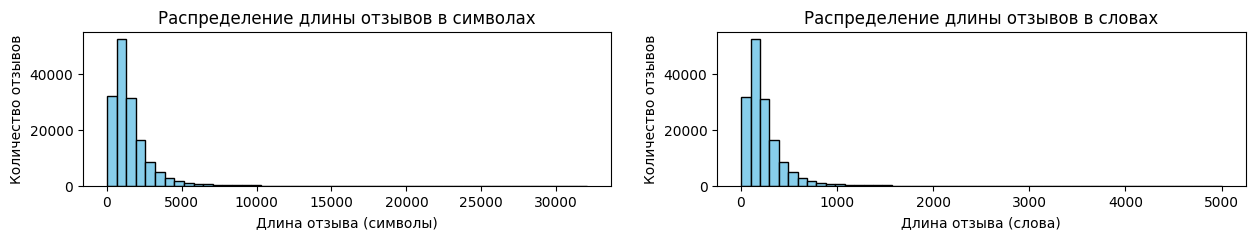

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 2))
axes[0].hist(df_text['char_count'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Длина отзыва (символы)')
axes[0].set_ylabel('Количество отзывов')
axes[0].set_title('Распределение длины отзывов в символах')

axes[1].hist(df_text['word_count'], bins=51, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Длина отзыва (слова)')
axes[1].set_ylabel('Количество отзывов')
axes[1].set_title('Распределение длины отзывов в словах')


### 1.3 Найти 10 самых частых:
- слов
- слов без стоп-слов
- лемм
- существительных

Топ 10 слов

In [ ]:
corpus = df_text['tokens'].explode()
word_counter = corpus.value_counts()
top_10_words = word_counter.head(10)
top_10_words

tokens
в        1322516
и        1054485
не        851742
на        704396
что       621783
я         573896
с         454545
по        365188
мне       320695
банка     263957
Name: count, dtype: int64

Топ 10 слов без стоп-слов

In [14]:
corpus = df_text['tokens_without_stop_words'].explode()
word_counter = corpus.value_counts()
top_10_words = word_counter.head(10)
top_10_words

tokens_without_stop_words
банка        263957
банк         196303
деньги       130062
карту        104947
карты        100877
кредит        80282
день          75996
заявление     69524
отделение     66468
время         65554
Name: count, dtype: int64

Топ 10 лемм

In [15]:
corpus = df_text['tokens_lemm'].explode()
word_counter = corpus.value_counts()
top_10_words = word_counter.head(10)
top_10_words

tokens_lemm
банк         624272
карта        331815
всё          189569
деньга       178338
день         172634
кредит       154865
отделение    143616
счёт         140509
сотрудник    133662
клиент       132908
Name: count, dtype: int64

Топ 10 существительных

In [16]:
corpus = df_text['tokens_lemm_noun'].explode()
word_counter = corpus.value_counts()
top_10_words = word_counter.head(10)
top_10_words

tokens_lemm_noun
банк         624272
карта        331815
деньга       178338
день         172634
кредит       154865
отделение    143616
счёт         140509
сотрудник    133662
клиент       132908
сумма        110914
Name: count, dtype: int64

In [20]:
top_10_words.values

array([624272, 331815, 178338, 172634, 154865, 143616, 140509, 133662,
       132908, 110914])

### Построить кривые Ципфа и Хипса

#### Кривая Ципфа

In [22]:
corpus = df_text['tokens_lemm'].explode()
word_counter = corpus.value_counts()
word_counter.values

array([624272, 331815, 189569, ...,      1,      1,      1],
      shape=(288443,))

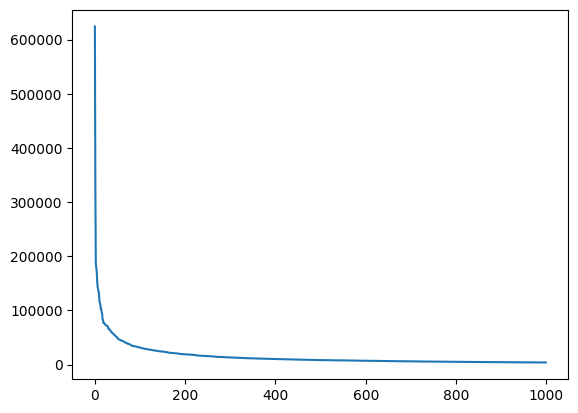

In [ ]:
freqs = list(word_counter.values)
fig, ax = plt.subplots()
ax.plot(range(1000), freqs[:1000])
plt.show()

#### Кривая Хипса

In [ ]:
punctuation = string.punctuation + "``''...«»"
punctuation

In [28]:
from tqdm import tqdm

cnt = Counter()
n_words = []
n_tokens = []
tokens = []
for index, row in tqdm(df_text.iterrows(), total = len(df_text)):
    tokens = word_tokenize(row['text'])
    cnt.update([token for token in tokens if token not in punctuation])
    n_words.append(len(cnt))
    n_tokens.append(sum(cnt.values()))

100%|██████████| 153499/153499 [14:00<00:00, 182.74it/s]


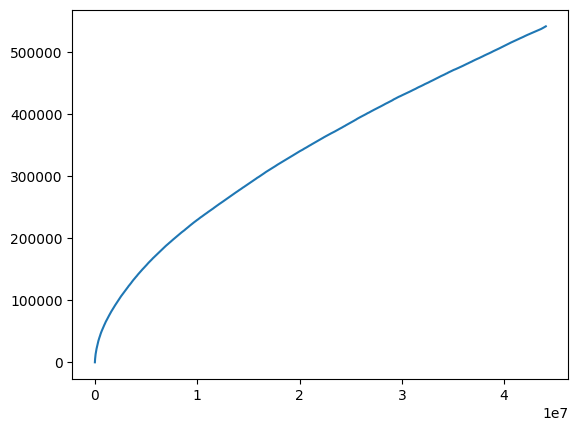

In [29]:
fig, ax = plt.subplots()
ax.plot(n_tokens, n_words)
plt.show()

### Ответить на следующие вопросы:
- какое слово встречается чаще, "сотрудник" или "клиент"?

In [35]:
corpus = df_text['tokens_lemm'].explode()
word_counter = corpus.value_counts()
if word_counter['сотрудник'] - word_counter['клиент'] > 0:
    print('Слово "сотрудник" встречается чаще, чем слово "клиент"')
elif word_counter['сотрудник'] - word_counter['клиент'] < 0:
    print('Слово "клиент" встречается чаще, чем слово "сотрудник"')
else:
    print('Оба слова встреаются с одной частотой')    


Слово "сотрудник" встречается чаще, чем слово "клиент"


- сколько раз встречаются слова "мошенничество" и "доверие"?

In [36]:
corpus = df_text['tokens_lemm'].explode()
word_counter = corpus.value_counts()
print(f"Солово 'мошенничество встречается {word_counter['мошенничество']} раз, а слово 'доверие' - {word_counter['доверие']} раз'")

Солово 'мошенничество встречается 3228 раз, а слово 'доверие' - 2098 раз'


## Часть 2. Тематическое моделирование

### Постройте несколько тематических моделей коллекции документов с разным числом тем.
Приведите примеры понятных (интерпретируемых) тем. Найдите темы, в которых упомянуты конкретные банки (Сбербанк, ВТБ, другой банк). Можете ли вы их прокомментировать / объяснить?
Эта часть задания может быть сделана с использованием gensim.

In [6]:
!pip install gensim

In [20]:
from gensim.corpora import Dictionary
from gensim.models import TfidfModel, lsimodel
# from gensim import similarities
from gensim.similarities import SparseMatrixSimilarity
import numpy as np


In [21]:
lemms = [token for token in df_text['tokens_lemm']]
# lemms[:10]

In [22]:
dictionary = Dictionary(lemms)
corpus = [dictionary.doc2bow(lemm) for lemm in lemms]
# corpus

In [10]:
tfidf = TfidfModel(corpus)

In [11]:
corpus_tfidf = tfidf[corpus]
corpus_tfidf

In [13]:
index = SparseMatrixSimilarity(
    corpus_tfidf, 
    num_features=len(dictionary)
)

#### Латентно-семантический анализ

In [25]:
lsi = lsimodel.LsiModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10
)

In [26]:
lsi.show_topics()

[(0,
  '0.608*"банк" + 0.341*"карта" + 0.175*"всё" + 0.151*"день" + 0.151*"деньга" + 0.138*"счёт" + 0.135*"кредит" + 0.128*"сотрудник" + 0.126*"отделение" + 0.124*"клиент"'),
 (1,
  '-0.826*"карта" + 0.392*"банк" + 0.248*"кредит" + 0.108*"договор" + -0.085*"сбербанк" + -0.082*"отделение" + 0.068*"платёж" + 0.065*"сумма" + -0.062*"банкомат" + 0.058*"документ"'),
 (2,
  '-0.575*"банк" + 0.313*"деньга" + -0.279*"карта" + 0.209*"день" + 0.207*"отделение" + 0.193*"сбербанк" + 0.187*"всё" + 0.178*"счёт" + 0.153*"сказать" + 0.147*"кредит"'),
 (3,
  '0.614*"кредит" + -0.322*"деньга" + -0.260*"вклад" + 0.235*"кредитный" + -0.212*"счёт" + 0.206*"карта" + -0.179*"банк" + 0.145*"сумма" + 0.135*"договор" + -0.134*"банкомат"'),
 (4,
  '0.431*"счёт" + 0.278*"сумма" + 0.275*"деньга" + -0.245*"всё" + 0.211*"средство" + -0.196*"отделение" + 0.151*"рубль" + 0.147*"платёж" + -0.139*"сотрудник" + -0.137*"клиент"'),
 (5,
  '-0.311*"деньга" + 0.296*"заявление" + 0.257*"сотрудник" + 0.240*"сбербанк" + -0.230*

"Сбербанко" упоминается втеме 5 наряду с такими словами, как заявление, сотрудник, отделение, номер. Вероятно, речь может идти об ответах сотрудников различных отделений себера на заявления клиентов.

In [27]:
lsi = lsimodel.LsiModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5
)

lsi.show_topics()

[(0,
  '0.608*"банк" + 0.341*"карта" + 0.175*"всё" + 0.151*"день" + 0.150*"деньга" + 0.138*"счёт" + 0.135*"кредит" + 0.128*"сотрудник" + 0.125*"отделение" + 0.124*"клиент"'),
 (1,
  '-0.826*"карта" + 0.391*"банк" + 0.247*"кредит" + 0.109*"договор" + -0.085*"сбербанк" + -0.083*"отделение" + 0.067*"платёж" + 0.064*"сумма" + -0.062*"банкомат" + 0.058*"документ"'),
 (2,
  '-0.577*"банк" + 0.301*"деньга" + -0.282*"карта" + 0.213*"отделение" + 0.205*"день" + 0.204*"сбербанк" + 0.191*"всё" + 0.160*"счёт" + 0.152*"сказать" + 0.141*"кредит"'),
 (3,
  '0.598*"кредит" + -0.352*"деньга" + -0.263*"вклад" + 0.233*"кредитный" + -0.220*"счёт" + 0.202*"карта" + -0.185*"банк" + -0.165*"банкомат" + 0.129*"договор" + 0.123*"сумма"'),
 (4,
  '0.367*"счёт" + 0.278*"сумма" + 0.269*"25d0" + -0.230*"всё" + 0.214*"деньга" + 0.212*"средство" + 0.169*"--" + 0.168*"договор" + -0.164*"отделение" + 0.153*"рубль"')]

Тема 2: упоминается "сбербанк" в контексте получения информации о счетах и кредитах

In [28]:
lsi = lsimodel.LsiModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=2
)

lsi.show_topics()

[(0,
  '0.608*"банк" + 0.341*"карта" + 0.175*"всё" + 0.151*"день" + 0.151*"деньга" + 0.138*"счёт" + 0.135*"кредит" + 0.128*"сотрудник" + 0.125*"отделение" + 0.124*"клиент"'),
 (1,
  '-0.825*"карта" + 0.391*"банк" + 0.250*"кредит" + 0.110*"договор" + -0.085*"сбербанк" + -0.083*"отделение" + 0.068*"платёж" + 0.065*"сумма" + -0.062*"банкомат" + 0.058*"документ"')]

Две темы - маловато будет. Сложно что-либо сказать. Возможно, во сторой теме речь идет о суммах платежей по кредиту в соответствии с договором.

In [ ]:
lsi = lsimodel.LsiModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=50
)

lsi.show_topics()

[(0,
  '0.608*"банк" + 0.341*"карта" + 0.175*"всё" + 0.151*"день" + 0.151*"деньга" + 0.138*"счёт" + 0.135*"кредит" + 0.128*"сотрудник" + 0.125*"отделение" + 0.124*"клиент"'),
 (1,
  '-0.826*"карта" + 0.392*"банк" + 0.248*"кредит" + 0.108*"договор" + -0.084*"сбербанк" + -0.083*"отделение" + 0.068*"платёж" + 0.065*"сумма" + -0.062*"банкомат" + 0.057*"документ"'),
 (2,
  '-0.574*"банк" + 0.319*"деньга" + -0.280*"карта" + 0.207*"отделение" + 0.205*"день" + 0.190*"сбербанк" + 0.189*"всё" + 0.177*"счёт" + 0.152*"сказать" + 0.146*"кредит"'),
 (3,
  '0.607*"кредит" + -0.336*"деньга" + -0.259*"вклад" + 0.234*"кредитный" + -0.204*"счёт" + 0.203*"карта" + -0.185*"банк" + -0.147*"банкомат" + 0.141*"сумма" + 0.134*"договор"'),
 (4,
  '0.430*"счёт" + 0.280*"сумма" + 0.269*"деньга" + -0.257*"всё" + 0.209*"средство" + -0.186*"отделение" + 0.151*"рубль" + 0.143*"платёж" + 0.133*"заявление" + -0.130*"клиент"'),
 (5,
  '0.983*"--" + -0.100*"деньга" + -0.045*"банк" + 0.045*"клиент" + 0.042*"ваш" + 0.037*"

## Часть 3. Классификация текстов

Сформулируем для простоты задачу бинарной классификации: будем классифицировать на два класса, то есть, различать резко отрицательные отзывы (с оценкой 1) и положительные отзывы (с оценкой 5).

### Составьте обучающее и тестовое множество: выберите из всего набора данных N1 отзывов с оценкой 1 и N2 отзывов с оценкой 5 (значение N1 и N2 – на ваше усмотрение). Используйте sklearn.model_selection.train_test_split для разделения

#### Выбираем записи со значениями `rating_grade` = 1 или 5

In [39]:
df_text['rating_grade'].unique()

array([nan,  2.,  1.,  5.,  3.,  4.])

In [4]:
df_filtered = df_text[(df_text['rating_grade'] == 1) | (df_text['rating_grade'] == 5)].copy()
df_filtered.head()

,text,rating_grade,tokens,tokens_without_stop_words,tokens_lemm,tokens_lemm_noun
19,Открыт вклад и счет в USD. Плюс к этому есть з...,1.0,"[открыт, вклад, и, счет, в, usd, плюс, к, этом...","[открыт, вклад, счет, usd, плюс, этому, зарпла...","[открыть, вклад, счёт, usd, плюс, зарплатный, ...","[вклад, счёт, карта, рубль, отделение, цель, с..."
33,Доброго времени! Вчера мне поступило смс-уведо...,1.0,"[доброго, времени, вчера, мне, поступило, смс-...","[доброго, времени, вчера, поступило, смс-уведо...","[добрый, время, вчера, поступить, смс-уведомле...","[время, смс-уведомление, банк, предложение, кр..."
76,"05.06.2015г. около 15 часов, пришел в указанны...",1.0,"[05.06.2015г, около, 15, часов, пришел, в, ука...","[05.06.2015г, около, 15, часов, пришел, указан...","[05.06.2015г, около, 15, час, прийти, указанны...","[05.06.2015г, час, офис, намерение, вклад, неб..."
85,Для оплаты коммунальных платежей пользуюсь пла...,1.0,"[для, оплаты, коммунальных, платежей, пользуюс...","[оплаты, коммунальных, платежей, пользуюсь, пл...","[оплата, коммунальный, платёж, пользоваться, п...","[оплата, платёж, карта, сайт, банк, пора, отчи..."
94,В апреле этого года пришла в отделение сбербан...,1.0,"[в, апреле, этого, года, пришла, в, отделение,...","[апреле, года, пришла, отделение, сбербанка, 6...","[апрель, год, прийти, отделение, сбербанк, 699...","[апрель, год, отделение, сбербанк, чапаевск, с..."


In [6]:
df_filtered['rating_grade'].value_counts().sort_index()

rating_grade
1.0    47387
5.0    14713
Name: count, dtype: int64

#### Делим датасет на обучающую и тестовую выборку

In [7]:
X = df_filtered['text']
y = df_filtered['rating_grade']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print("="*50)
print("РЕЗУЛЬТАТЫ РАЗБИЕНИЯ")
print("="*50)
print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")
print(f"Соотношение: {len(X_train)/len(df_filtered):.1%} / {len(X_test)/len(df_filtered):.1%}")

print("\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts().sort_index())
print(f"\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts().sort_index())

РЕЗУЛЬТАТЫ РАЗБИЕНИЯ
Размер обучающей выборки: 49680
Размер тестовой выборки: 12420
Соотношение: 80.0% / 20.0%

Распределение классов в обучающей выборке:
rating_grade
1.0    37910
5.0    11770
Name: count, dtype: int64

Распределение классов в тестовой выборке:
rating_grade
1.0    9477
5.0    2943
Name: count, dtype: int64


### Используйте любой известный вам алгоритм классификации текстов для решения задачи и получите baseline.
Сравните разные варианты векторизации текста: использование только униграм, пар или троек слов или с использованием символьных $n$-грам.

#### Для обучения используем необработанный текст

In [12]:
pipline = Pipeline([
    ('cv', CountVectorizer(ngram_range=(1, 1))),
    ('clf', LogisticRegression(random_state=42))
])

pipline.fit(X_train, y_train)
pred = pipline.predict(X_test)
print(classification_report(y_test, pred))

/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

         1.0       0.98      0.98      0.98      9477
         5.0       0.94      0.92      0.93      2943

    accuracy                           0.97     12420
   macro avg       0.96      0.95      0.96     12420
weighted avg       0.97      0.97      0.97     12420



In [13]:
pipline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 1))),
    ('clf', LogisticRegression(random_state=42))
])

pipline.fit(X_train, y_train)
pred = pipline.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         1.0       0.97      0.99      0.98      9477
         5.0       0.97      0.88      0.93      2943

    accuracy                           0.97     12420
   macro avg       0.97      0.94      0.95     12420
weighted avg       0.97      0.97      0.97     12420



In [14]:
pipline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(2, 2))),
    ('clf', LogisticRegression(random_state=42))
])

pipline.fit(X_train, y_train)
pred = pipline.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         1.0       0.92      1.00      0.96      9477
         5.0       0.99      0.70      0.82      2943

    accuracy                           0.93     12420
   macro avg       0.95      0.85      0.89     12420
weighted avg       0.93      0.93      0.92     12420



### Сравните, как изменяется качество решения задачи при использовании скрытых тем в качестве признаков:
- 1-ый вариант: $tf-idf$ преобразование (sklearn.feature_extraction.text.TfidfTransformer) и сингулярное разложение (оно же – латентый семантический анализ) (sklearn.decomposition.TruncatedSVD),
- 2-ой вариант: тематические модели LDA (sklearn.decomposition.LatentDirichletAllocation).
Используйте accuracy и F-measure для оценки качества классификации.

В ноутбуке, размещенном в папке репозитория. написан примерный Pipeline для классификации текстов.

Эта часть задания может быть сделана с использованием sklearn.

In [ ]:
pipline_lsi = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        min_df=5,
        max_df=0.8
    )),
    ('lsi', TruncatedSVD(
        n_components=100,
        random_state=42    
    )),    
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

pipline_lsi.fit(X_train, y_train)
pred_lsi = pipline_lsi.predict(X_test)
print(classification_report(y_test, pred_lsi))

              precision    recall  f1-score   support

         1.0       0.90      0.99      0.94      9477
         5.0       0.96      0.65      0.77      2943

    accuracy                           0.91     12420
   macro avg       0.93      0.82      0.86     12420
weighted avg       0.92      0.91      0.90     12420



#### Построим модели на лемматизированном тексте

In [5]:
df_filtered['tokens_lemm_text'] = df_filtered['tokens_lemm'].apply(lambda x: ' '.join(x))
df_filtered['tokens_lemm_text'].head()

19    открыть вклад счёт usd плюс зарплатный карта р...
33    добрый время вчера поступить смс-уведомление б...
76    05.06.2015г около 15 час прийти указанный офис...
85    оплата коммунальный платёж пользоваться пласти...
94    апрель год прийти отделение сбербанк 6991/0571...
Name: tokens_lemm_text, dtype: object

In [6]:
X = df_filtered['tokens_lemm_text']
y = df_filtered['rating_grade']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
base_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        min_df=5,
        max_df=0.8
    )),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

base_pipeline.fit(X_train, y_train)
base_pred = base_pipeline.predict(X_test)
print(classification_report(y_test, base_pred))

              precision    recall  f1-score   support

         1.0       0.80      1.00      0.89      9477
         5.0       1.00      0.21      0.35      2943

    accuracy                           0.81     12420
   macro avg       0.90      0.61      0.62     12420
weighted avg       0.85      0.81      0.76     12420



In [8]:
lsi_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        min_df=5,
        max_df=0.8
    )),
    ('lsi', TruncatedSVD(
        n_components=100,
        random_state=42
    )),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

lsi_pipeline.fit(X_train, y_train)
lsi_pred = lsi_pipeline.predict(X_test)
print(classification_report(y_test, lsi_pred))

              precision    recall  f1-score   support

         1.0       0.89      0.99      0.94      9477
         5.0       0.96      0.58      0.73      2943

    accuracy                           0.90     12420
   macro avg       0.92      0.79      0.83     12420
weighted avg       0.90      0.90      0.89     12420



In [9]:
lsi_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 1),
        max_features=10000,
        min_df=5,
        max_df=0.8
    )),
    ('lsi', TruncatedSVD(
        n_components=100,
        random_state=42
    )),
    ('clf', LogisticRegression(
        random_state=42
    ))
])

lsi_pipeline.fit(X_train, y_train)
lsi_pred = lsi_pipeline.predict(X_test)
print(classification_report(y_test, lsi_pred))

              precision    recall  f1-score   support

         1.0       0.95      0.98      0.97      9477
         5.0       0.93      0.85      0.89      2943

    accuracy                           0.95     12420
   macro avg       0.94      0.91      0.93     12420
weighted avg       0.95      0.95      0.95     12420

